In [2]:
# === Cell 1: imports + load ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

DATA_CACHE   = Path('data') / 'features'

df = pd.read_parquet(DATA_CACHE / 'cereal_features.parquet')
print(f'Loaded: {df.shape}')
print(f'Date range: {df["WEEK_END_DATE"].min().date()} → {df["WEEK_END_DATE"].max().date()}')

Loaded: (169676, 40)
Date range: 2009-01-14 → 2012-01-04


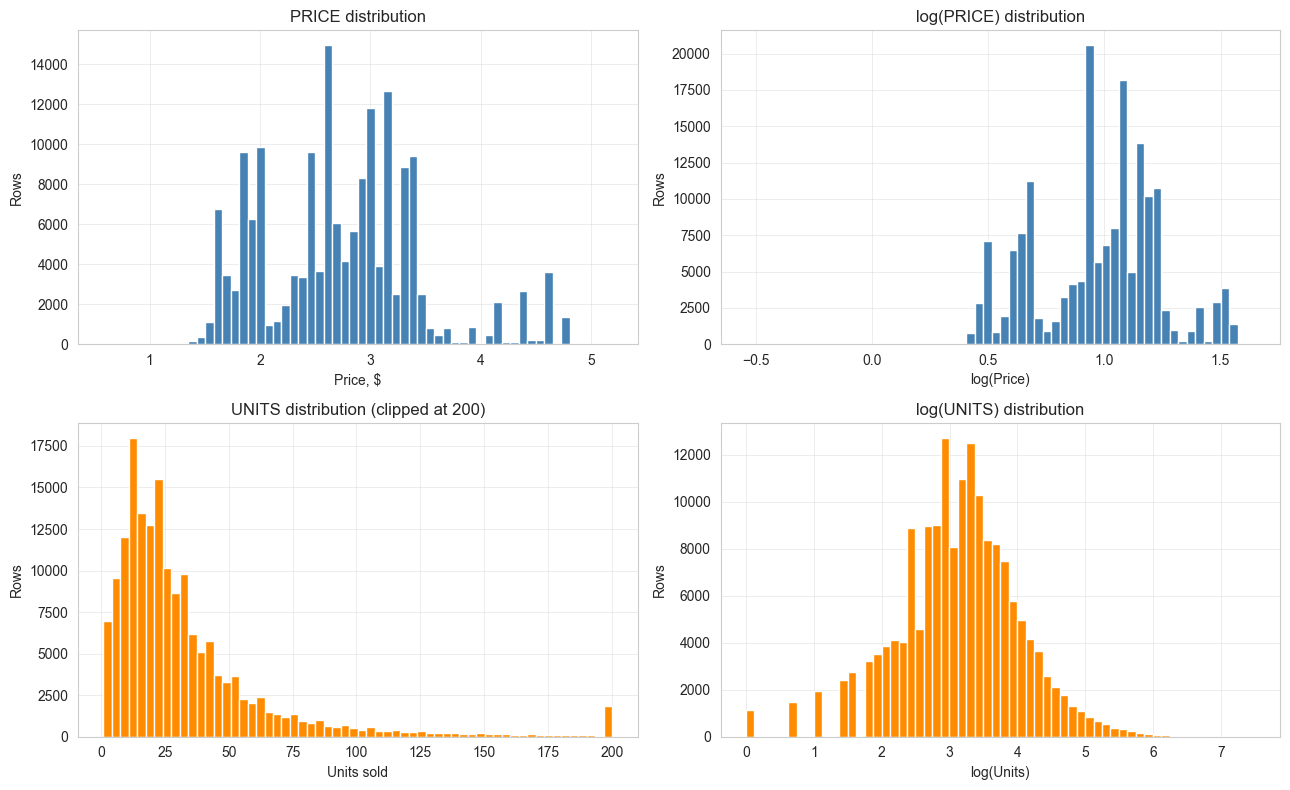


PRICE  | mean: 2.74, median: 2.72, std: 0.71
UNITS  | mean: 34.3, median: 24, std: 41.4


In [3]:
# === Cell 2: распределения цены и продаж ===
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Сырая цена
axes[0, 0].hist(df['PRICE'], bins=60, edgecolor='white', color='steelblue')
axes[0, 0].set_title('PRICE distribution')
axes[0, 0].set_xlabel('Price, $'); axes[0, 0].set_ylabel('Rows')

# Логарифм цены
axes[0, 1].hist(df['log_price'], bins=60, edgecolor='white', color='steelblue')
axes[0, 1].set_title('log(PRICE) distribution')
axes[0, 1].set_xlabel('log(Price)'); axes[0, 1].set_ylabel('Rows')

# Сырые продажи (с лимитом — длинный хвост)
axes[1, 0].hist(df['UNITS'].clip(upper=200), bins=60, edgecolor='white', color='darkorange')
axes[1, 0].set_title('UNITS distribution (clipped at 200)')
axes[1, 0].set_xlabel('Units sold'); axes[1, 0].set_ylabel('Rows')

# Логарифм продаж
axes[1, 1].hist(df['log_units'], bins=60, edgecolor='white', color='darkorange')
axes[1, 1].set_title('log(UNITS) distribution')
axes[1, 1].set_xlabel('log(Units)'); axes[1, 1].set_ylabel('Rows')

plt.tight_layout()
plt.show()

print('\nPRICE  | mean: {:.2f}, median: {:.2f}, std: {:.2f}'.format(
    df['PRICE'].mean(), df['PRICE'].median(), df['PRICE'].std()))
print('UNITS  | mean: {:.1f}, median: {:.0f}, std: {:.1f}'.format(
    df['UNITS'].mean(), df['UNITS'].median(), df['UNITS'].std()))